# Black–Scholes Model for European Call Options

We consider the pricing of a European call option under the Black–Scholes framework.

## Model parameters

The model depends on the following parameters:

- $S$ : price of the underlying asset  
- $K$ : strike price  
- $T$ : maturity time  
- $t$ : current time ($0 \le t \le T$)  
- $r$ : constant risk-free interest rate  
- $\sigma$ : volatility of the underlying asset  

A European call option gives the holder the right (but not the obligation) to buy the asset at time $T$ for the price $K$.

The payoff at maturity is

$$
g(S) = \max(S-K,0).
$$



# Black–Scholes equation

Let $V(t,S)$ denote the price of the option at time $t$ when the asset price is $S$.

Under the Black–Scholes assumptions, $V$ satisfies the PDE (see the paper attached to the notebook for more details)

$$
\frac{\partial V}{\partial t}
+ \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ rS\frac{\partial V}{\partial S}
- rV = 0,
\qquad (t,S) \in [0,T) \times (0,\infty).
$$

The terminal condition is given by the payoff:

$$
V(T,S) = \max(S-K,0).
$$



# Solution

The Black–Scholes formula gives an explicit solution for the European call price:

$$
V(t,S) =
S \Phi(d_1)
-
K e^{-r(T-t)} \Phi(d_2),
$$

where $\Phi$ is the cumulative distribution function of the standard normal distribution and

$$
d_1 =
\frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)(T-t)}
{\sigma \sqrt{T-t}},
$$

$$
d_2 = d_1 - \sigma\sqrt{T-t}.
$$


The formula depends on the quantity

$$
\tau = T - t,
$$

which represents the time remaining until maturity.  


In [ ]:
import numpy as np
from scipy.linalg import solve_banded
import matplotlib.pyplot as plt
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

### STEP 1: Implementing the solution

In [ ]:
S0 = 190.99    # stock price nvidia
K = 190.0      # Strike 
T = 1.0        # one year
r = 0.05       # risk-free rate
sigma = 0.45   # volatility

def bs_call_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)

bs_call_price(S0, K, T, r, sigma)


np.float64(38.459807129547485)

The price for the call option on NVIDIA is 38.459807129547485 for one year left to maturity.

## Binomial tree pricing (Cox-Ross–Rubinstein model)

The following function computes the price of a European call option using the binomial tree method.  
This numerical method approximates the evolution of the asset price by a discrete-time tree.

### Model idea

Over a small time step $\Delta t = T/N$, the asset price can move:

- up by a factor  
  $$u = e^{\sigma \sqrt{\Delta t}}
  $$

- down by a factor  
  $$d = \frac{1}{u}
  $$

Under the risk-neutral measure, the probability of an upward move is

$$q = \frac{e^{r\Delta t} - d}{u - d}.
$$

### Algorithm

1. Discretization of time

   The maturity $T$ is divided into $N$ steps:

   $$\Delta t = \frac{T}{N}.
   $$

2. Terminal asset prices

   At maturity, the asset can reach $N+1$ possible values:

   $$S_T = S_0 u^{N-i} d^i, \quad i=0,\dots,N.
   $$

3. Option payoff

   The value of the call option at maturity is given by the payoff

   $$\max(S_T - K, 0).
   $$

4. Backward induction

   The option price is then computed recursively from the final nodes to the initial node using risk-neutral valuation:

   $$V = e^{-r\Delta t} \left(q V_{\text{up}} + (1-q)V_{\text{down}}\right).$$

5. Initial price

   The value obtained at the root of the tree corresponds to the option price at time $t=0$.

### Numerical experiment

In the notebook, the binomial price is computed with $N=500$ time steps and compared with the analytical Black–Scholes price.

In [ ]:

def binomial_call(S, K, T, r, sigma, N):
    dt_b =T / N
    u_fact = np.exp(sigma *np.sqrt(dt_b))
    d_fact = 1 / u_fact
    q = (np.exp(r * dt_b) -d_fact) /(u_fact- d_fact)
    
    # final price nodes
    ST = S * (u_fact**np.arange(N, -1, -1)) * (d_fact**np.arange(0, N + 1, 1))
    values = np.maximum(ST - K, 0)
    
    # going backward
    for i in range(N - 1, -1, -1):
        values = np.exp(-r * dt_b) * (q * values[:-1] + (1 - q) * values[1:])
    return values[0]

# compute the price
crr_price = binomial_call(S0, K, T, r, sigma, 500)
bs_price = bs_call_price(S0, K, T, r, sigma) 
print(crr_price)

38.45768885034708


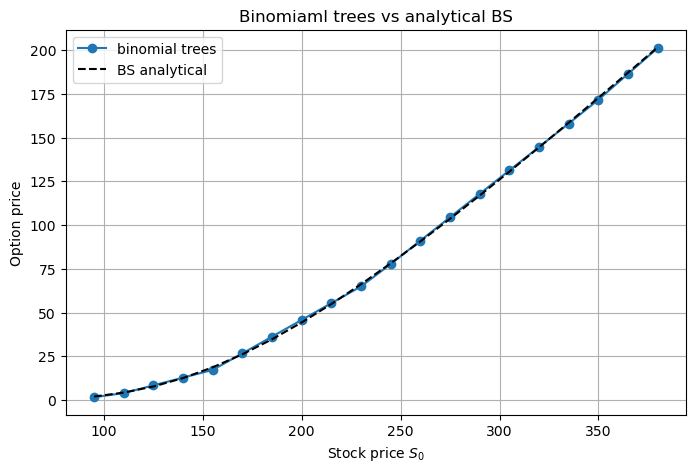

In [ ]:
S0_grid = np.linspace(0.5*190, 2*190, 20)
K, T, r, sigma = 190, 1.0, 0.05, 0.45


bs_prices = bs_call_price(S0_grid, K, T, r, sigma)

plt.figure(figsize=(8, 5))
prices = [binomial_call(S0_i, K, T, r, sigma, 5) for S0_i in S0_grid]

plt.plot(S0_grid, prices, 'o-', label=f'binomial trees')
plt.plot(S0_grid, bs_prices, 'k--', label='BS analytical')

plt.title(f"Binomiaml trees vs analytical BS")
plt.xlabel("Stock price $S_0$")
plt.ylabel("Option price")
plt.legend()
plt.grid(True)

plt.show()
    

## Finite difference method for European option 

In this section we compute the price of a European call option by solving the Black–Scholes partial differential equation numerically using finite difference methods.
The Black–Scholes equation for the option price $V(S,t)$ is

$$
\frac{\partial V}{\partial t}
+ \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ rS \frac{\partial V}{\partial S}
- rV = 0
$$

with terminal payoff

$$
V(S,T) = \max(S-K,0).
$$

To simplify the numerical solution we introduce the log–price variable

$$
x = \ln(S)
$$

and apply the transformation

$$
V(S,t) = e^{a x + b\tau} u(x,\tau)
$$

where

$$
\tau = T - t.
$$

The constants are defined as

$$
\alpha = \frac{1}{2}\sigma^2, \qquad
\beta = r - \frac{1}{2}\sigma^2
$$

and

$$
a = -\frac{\beta}{2\alpha}, \qquad
b = -\frac{\beta^2}{4\alpha} - r.
$$

With this change of variables the Black–Scholes equation transforms into the heat equation

$$
u_\tau - \frac{\sigma^2}{2} u_{xx} = 0
\qquad (\tau,x)\in (0,T)\times\Omega
$$
with omega the truncated domain 

$$\Omega = (x_{\min}, x_{\max}), \quad x = \ln(S),$$



### FDM

Discretize $u_{xx}$ using central differences:

$$
u_{xx} \approx \frac{u_{j-1} - 2 u_j + u_{j+1}}{h_x^2}.
$$

Define the tridiagonal matrix $A \in \mathbb{R}^{J\times J}$:

$$
A = \frac{1}{h_x^2} 
\begin{bmatrix}
-2 & 1 & 0 & \cdots & 0 \\
1 & -2 & 1 & \cdots & 0 \\
0 & \ddots & \ddots & \ddots & 0 \\
0 & \cdots & 1 & -2 & 1 \\
0 & \cdots & 0 & 1 & -2
\end{bmatrix},
$$

so the semi-discrete FDM system is
$$
\frac{d\mathbf{V}}{d\tau} = \alpha A \mathbf{V}.
$$

We still need time discretization, so we use Euler methods

### Grid construction

The spatial domain is chosen around the strike pricewhich captures most of the relevant region of the asset price distribution.

The grid uses:
- $J$ spatial steps  
- $N$ time steps  

with mesh sizes
$$
h_x = \frac{x_{\max}-x_{\min}}{J+1}, \qquad
h_t = \frac{T}{N}.
$$


### Finite difference Euler methods

Three numerical schemes are implemented:
- Explicit scheme  
$$
V^{n+1} = (I - h_t \alpha A) V^n
$$

- Implicit scheme  
$$
(I + h_t \alpha A) V^{n+1} = V^n$$

- Crank–Nicolson scheme  
$$\left(I + \frac{h_t}{2} \alpha A\right) V^{n+1} = \left(I - \frac{h_t}{2} \alpha A\right) V^n$$

### Recovering the price

After solving the heat equation backwards in time, the original option price is obtained from

$$
V(S_0,0) = e^{a x + bT} u(x,T)
$$

with $x=\ln(S_0)$.

In [ ]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

def price_call_fdm(S0, K, T, r, sigma, J=200, N=2000, method='cn',S_max_mult=2.0, return_surface=False):
    alpha = 0.5 * sigma**2
    beta = r - 0.5 * sigma**2
    # coefficients for the heat equation
    a_bs = -beta / (2*alpha)
    b_bs = -(beta**2)/(4*alpha) - r
    

    #discretisation around log(K)
    S_max = S_max_mult * K
    x_min = np.log(K) - 5*sigma*np.sqrt(T)
    x_max = np.log(K) + 5*sigma*np.sqrt(T)
    x = np.linspace(x_min, x_max, J +2)  
    hx = (x_max - x_min) / (J + 1)
    ht = T / N
    
    x_int = x[1:-1]
    
    # intiial condition
    u = np.exp(-a_bs * x_int) * np.maximum(np.exp(x_int) - K, 0)

    if return_surface:
        surface = np.zeros((N+1, J))
        surface[0, :] = u.copy()
    
    # matrix Ahx
    main_diag = 2.0 * np.ones(J)
    off_diag = -1.0 * np.ones(J-1)
    A = diags([off_diag, main_diag, off_diag], [-1, 0, 1]) / hx**2
    I = diags([np.ones(J)], [0])
    
    # compute the crank-nicholson matrices
    if method == 'cn':
        L = (I + 0.5*ht*alpha*A).tocsc()
        R = I - 0.5*ht*alpha*A
    
    # time discretisation
    for n in range(N):
        tau_n = n*ht
        u_left = 0.0 #deep out-of-the-monet
        u_right = 0.0 # deep in-the-money
        
        if method == 'explicit':
            B = I - ht * alpha * A
            rhs = B @u
            rhs[0] += ht * alpha / hx**2 * u_left
            rhs[-1] += ht * alpha / hx**2 * u_right
            u = rhs
        elif method == 'implicit':
            L_imp = (I + ht * alpha * A).tocsc()
            rhs = u.copy()
            rhs[0] += ht * alpha / hx**2 * u_left
            rhs[-1] += ht * alpha / hx**2 * u_right
            u = spsolve(L_imp, rhs)
        elif method == 'cn':
            rhs = R @ u
            rhs[0] += 0.5 * ht * alpha / hx**2 * u_left
            rhs[-1] += 0.5 * ht * alpha / hx**2 * u_right
            u = spsolve(L, rhs)
        else:
            raise ValueError("Unknown method")
        
        if return_surface:
            surface[n+1, :] = u.copy()
    

    if return_surface:
        return surface, x_int, np.linspace(0, T, N+1)
    else:
   
        x_target = np.log(S0)
        idx = np.abs(x_int - x_target).argmin()
        price = np.exp(a_bs *x_int[idx] + b_bs * T) * u[idx]
        return price

S0 = 190.99
K = 190.0
T = 1.0
r = 0.05
sigma = 0.45

p_explicit = price_call_fdm(S0, K, T, r, sigma, method='explicit', S_max_mult=2.0, return_surface=False)
p_implicit = price_call_fdm(S0, K, T, r, sigma, method='implicit',S_max_mult=2.0, return_surface=False)
p_cn = price_call_fdm(S0, K, T, r, sigma, method='cn',S_max_mult=2.0, return_surface=False)

print(f"Explicit price: {p_explicit:.6f}")
print(f"Implicit price: {p_implicit:.6f}")
print(f"Crank-Nicolson price: {p_cn:.6f}")

Explicit price: 39.194881
Implicit price: 39.191329
Crank-Nicolson price: 39.193105


## Visualizing FDM prices vs Black-Scholes

We now compare the prices of a European call option computed with different finite difference methods (explicit, implicit, and Crank-Nicolson) to the analytical solution. 
- We vary the initial stock price \(S_0\) from 50% to 200% of the strike price $K = 190$.  
- FDM parameters: $J = 90$ spatial steps, $N = 9000$ time steps.  

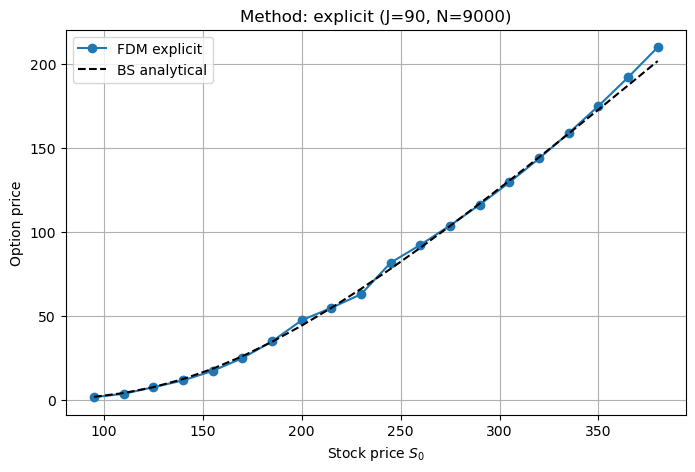

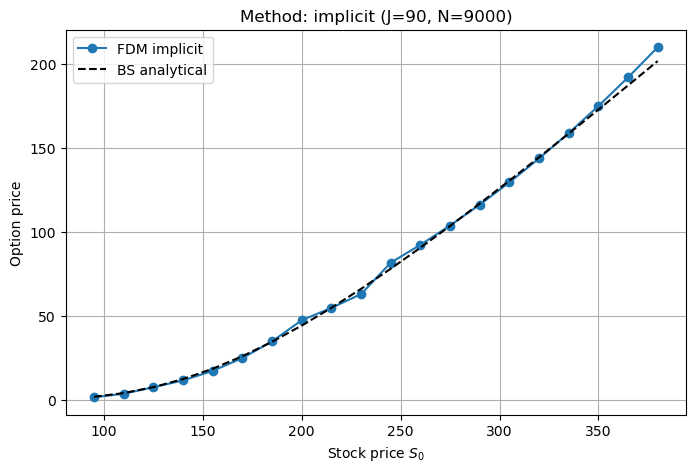

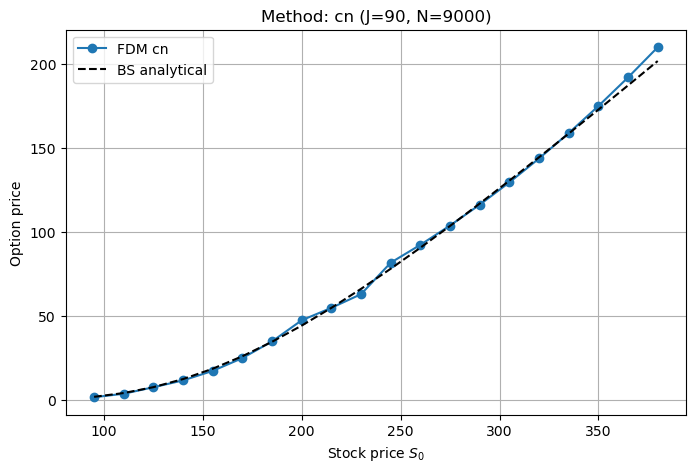

In [ ]:

S0_grid = np.linspace(0.5*190, 2*190, 20)
K, T, r, sigma = 190, 1.0, 0.05, 0.45
methods = ['explicit', 'implicit', 'cn']
params = {'J': 90, 'N': 9000} 

bs_prices = bs_call_price(S0_grid, K, T, r, sigma)

for method in methods:
    plt.figure(figsize=(8, 5))
    prices = [price_call_fdm(S0_i, K, T, r, sigma, 
                             J=params['J'], N=params['N'], 
                             method=method) for S0_i in S0_grid]

    plt.plot(S0_grid, prices, 'o-', label=f'FDM {method}')
    plt.plot(S0_grid, bs_prices, 'k--', label='BS analytical')

    plt.title(f"Method: {method} (J={params['J']}, N={params['N']})")
    plt.xlabel("Stock price $S_0$")
    plt.ylabel("Option price")
    plt.legend()
    plt.grid(True)

    plt.show()

## Unstability

For the explicit euler method, the CFL condition is :

$$
h_t\le \frac{h_x^2}{\sigma^2}.
$$

In this cell, we used:
- Very fine spatial grid: \(J = 200\)
- Very few time steps: \(N = 10\)
which violate the CFL condition, creating unstability.

The resulting option prices show extremely large oscillations, on the order of $$ \pm 2 \times 10^{17} $$.

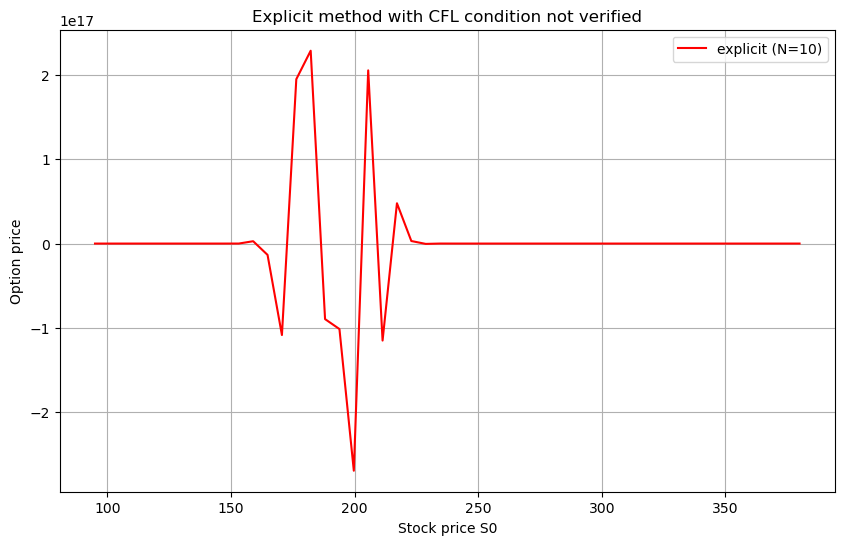

In [ ]:

S0_grid = np.linspace(0.5*190, 2*190, 50)
N_small = 10   #intentionally small to violate CFL
method = 'explicit'

prices = [price_call_fdm(S0_i, 190, 1.0, 0.05, 0.45, J=200, N=N_small, method=method) for S0_i in S0_grid]

plt.figure(figsize=(10,6))
plt.plot(S0_grid, prices, 'r', label=f'{method} (N={N_small})')
plt.xlabel("Stock price S0")
plt.ylabel("Option price")
plt.title("Explicit method with CFL condition not verified")
plt.legend()
plt.grid(True)
plt.show()

## Overall
This section evaluates the performance of the three finite difference schemes by comparing their numerical results against the Black-Scholes analytical solution. The goal is to visualize the implications of the Lax equivalence theorem, which states that a consistent and stable method is convergent.

We observe that the explicit method is more unstable than the others.

More, because the heat equation is dissipative (f=0), the the numerical error remains controlled and does not grow exponentially provided the stability conditions are met (here for the Crank-Nicholson and implicit schemes)

We imposed Dirichlet boundary conditions $u=0$ at $x_{min}$ and $x_{max}$.
As the stock price $S$ approaches the grid boundary, the numerical solution is pulled toward zero (because of the forced boundary), diverging from the analytical solution.

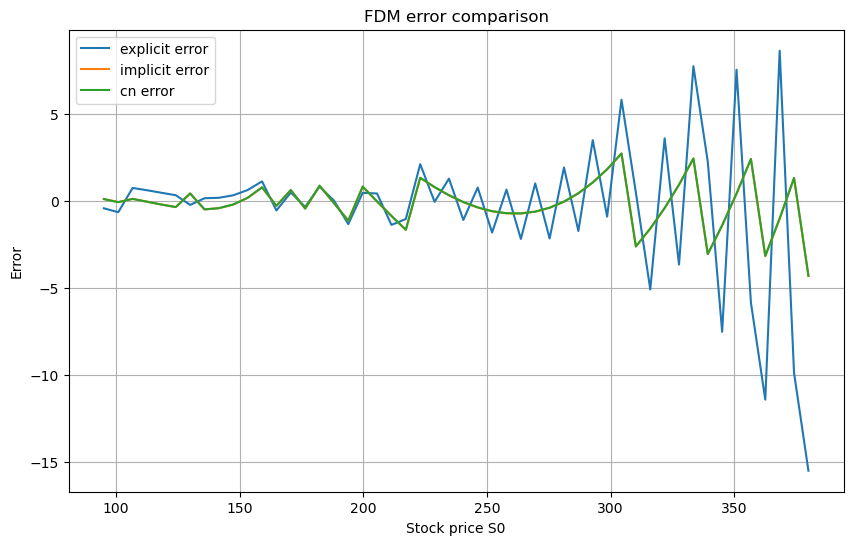

In [ ]:
plt.figure(figsize=(10,6))
for method in methods:
    prices = [price_call_fdm(S0_i, 190, 1.0, 0.05, 0.45, J=200, N=400, method=method) for S0_i in S0_grid]
    error = np.array(prices) - bs_call_price(S0_grid, 190, 1.0, 0.05, 0.45)
    plt.plot(S0_grid, error, label=f'{method} error')

plt.xlabel("Stock price S0")
plt.ylabel("Error")
plt.title("FDM error comparison")
plt.legend()
plt.grid(True)
plt.show()

## Surface

The 3D surface shows the option price as a function of stock price and time, computed on a discretized grid with J = 100 spatial points and N = 300 time steps.

At time t=0 (the front edge of the mesh), the initial call option payoff is visible with its characteristic spike at the strike price. As t increases, this sharp corner is smoothed out. This demonstrates the regularizing effect of the PDE (see the paper for details). More, the surface is smooth for the implicit scheme, because the method is stable.
At the edges of the stock price axis, the surface pulls towards zero, because of the Dirichlet conditions.

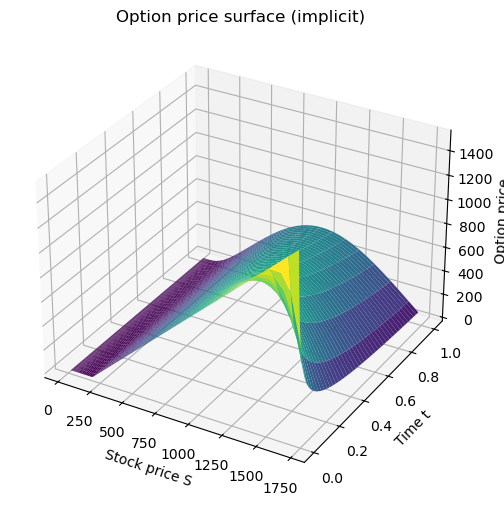

In [ ]:
S0 = 190.99    # stock price nvidia
K = 190.0      # Strike 
T = 1.0        # one year
r = 0.05       # risk-free rate
sigma = 0.45
method = 'implicit'

surface, x_int, tau = price_call_fdm(S0, K, T, r, sigma, J=100, N=300, method=method, return_surface=True)

alpha = 0.5*sigma**2
beta = r - 0.5*sigma**2
a_bs = -beta/(2*alpha)
b_bs = -(beta**2)/(4*alpha)-r

S_grid = np.exp(x_int)
surface_prices = np.exp(a_bs*x_int[None,:] + b_bs*tau[:,None]) *surface

X, Y = np.meshgrid(S_grid, tau)
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, surface_prices, cmap='viridis')
ax.set_xlabel("Stock price S")
ax.set_ylabel("Time t")
ax.set_zlabel("Option price")
ax.set_title(f"Option price surface ({method})")
plt.show()

For an explicit scheme without CFL:

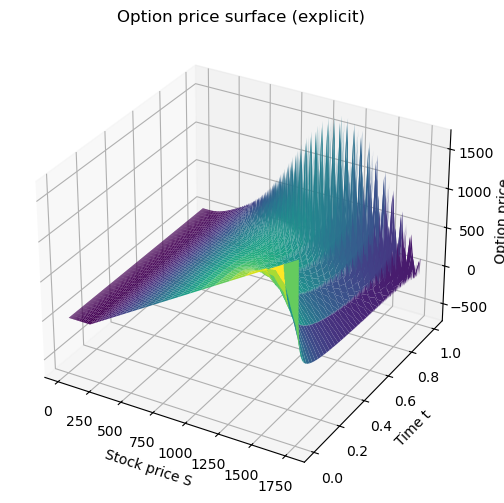

In [ ]:
S0 = 190.99    # stock price nvidia
K = 190.0      # Strike 
T = 1.0        # one year
r = 0.05       # risk-free rate
sigma = 0.45
method = 'explicit'

surface, x_int, tau = price_call_fdm(S0, K, T, r, sigma, J=200, N=400, method=method, return_surface=True)

alpha = 0.5*sigma**2
beta = r - 0.5*sigma**2
a_bs = -beta/(2*alpha)
b_bs = -(beta**2)/(4*alpha)-r

S_grid = np.exp(x_int)
surface_prices = np.exp(a_bs*x_int[None,:] + b_bs*tau[:,None]) *surface

X, Y = np.meshgrid(S_grid, tau)
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, surface_prices, cmap='viridis')
ax.set_xlabel("Stock price S")
ax.set_ylabel("Time t")
ax.set_zlabel("Option price")
ax.set_title(f"Option price surface ({method})")
plt.show()

## Computing Greeks from the FDM surface

Once we have computed the option price surface V(S, t), we can estimate the Greeks, which measure the sensitivity of the option price to underlying parameters:

- **Delta**: Sensitivity to the underlying stock price
$$
\Delta = \frac{\partial V}{\partial S}
$$
$$
\Delta(S, t) = \frac{\partial V}{\partial S} \approx \frac{V(S+h, t) - V(S-h, t)}{2h}
$$
- **Gamma**: Sensitivity of Delta to the stock price


$$
\Gamma = \frac{\partial^2 V}{\partial S^2}
$$
$$
\Gamma(S, t) = \frac{\partial^2 V}{\partial S^2} \approx \frac{V(S+h, t) - 2V(S, t) + V(S-h, t)}{h^2}
$$

- **Theta**: Sensitivity to time
$$
\Theta = \frac{\partial V}{\partial t}
$$
$$
\Theta(S, t) = \frac{\partial V}{\partial t} \approx \frac{V(S, t) - V(S, t-\Delta t)}{\Delta t}
$$


Below, we compute the Greeks from our previously calculated FDM surface for an implicit scheme.

In [ ]:
S0 = 190.99    # stock price nvidia
K = 190.0      # Strike 
T = 1.0        # one year
r = 0.05       # risk-free rate
sigma = 0.45
method = 'implicit'

surface, x_int, tau = price_call_fdm(S0, K, T, r, sigma, J=100, N=300, method=method, return_surface=True)

alpha = 0.5*sigma**2
beta = r - 0.5*sigma**2
a_bs = -beta/(2*alpha)
b_bs = -(beta**2)/(4*alpha)-r

S_grid = np.exp(x_int)
surface_prices = np.exp(a_bs*x_int[None,:] + b_bs*tau[:,None]) *surface


def compute_fdm_greeks(S_grid, tau_grid, surface_prices):
    V = surface_prices[-1, :]
    S = S_grid
    
    # delta
    delta = np.zeros_like(V)
    delta[1:-1] = (V[2:] - V[:-2]) / (S[2:] - S[:-2])
    delta[0] = (V[1] -V[0]) / (S[1] -S[0])
    delta[-1] = (V[-1] -V[-2]) / (S[-1] -S[-2])

    #gamma
   
    gamma = np.zeros_like(V)
    h = np.diff(S)
    gamma[1:-1] = ((V[2:] - V[1:-1]) / h[1:] -(V[1:-1] -V[:-2]) /h[:-1]) /(0.5*(S[2:] -S[:-2]))
    gamma[0] = gamma[1]  
    gamma[-1] = gamma[-2]
    
    # theta
    theta = (surface_prices[-1, :] - surface_prices[-2, :]) / (tau_grid[-1] - tau_grid[-2])
    
    return delta, gamma, theta

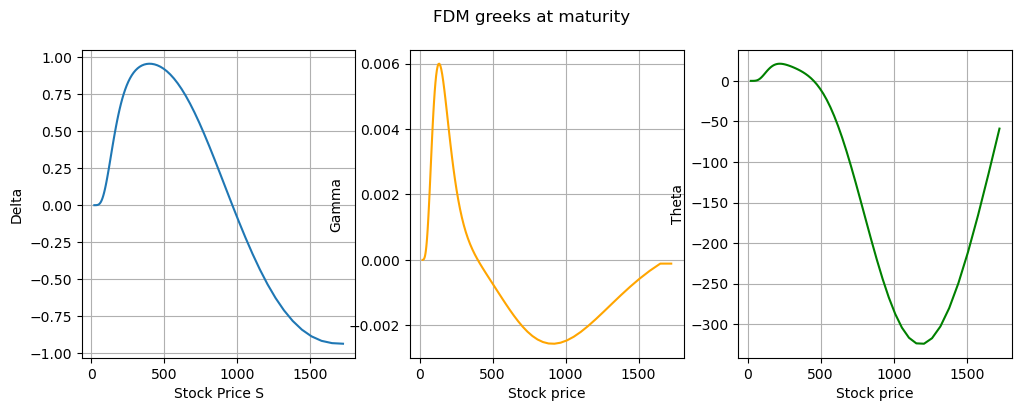

In [ ]:
delta, gamma, theta = compute_fdm_greeks(S_grid, tau, surface_prices)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(S_grid, delta, label='Delta')
plt.xlabel("Stock Price (S)")
plt.ylabel("Delta")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(S_grid, gamma, label='Gamma', color='orange')
plt.xlabel("Stock Price (S)")
plt.ylabel("Gamma")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(S_grid, theta, label='Theta', color='green')
plt.xlabel("Stock Price (S)")
plt.ylabel("Theta")
plt.grid(True)

plt.suptitle("FDM greeks at maturity")
plt.show()